##                      Homework 2: Improving Image Classification Performance on the MNIST Dataset

#### Objective

#### In this assignment, you will:

1. Build and evaluate an MLP and a CNN on the MNIST dataset.
2. Experiment with 
3. Explore how training data proportions (10% vs. 30%), network design, and other hyper parameter configurations (e.g. learning rate) affect model performance.
4. Bonus: Achieve high test accuracy (≥98%) with your CNN model using 30% of training data.

## 🪄 Step 0: Setup

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

## Step 1: Load MNIST Dataset

In [21]:
# Transform: convert images to tensors and normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Training samples: {len(train_dataset)}, Testing samples: {len(test_dataset)}")


Training samples: 60000, Testing samples: 10000


# Step 2: Load Only 10% of the Training Data

In [22]:
torch.manual_seed(42)  # fixed seed for reproducibility
train_size = int(0.1 * len(train_dataset))
_, small_train_dataset = random_split(train_dataset, [len(train_dataset) - train_size, train_size])

batch_size = 32

train_loader = DataLoader(small_train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Subset training samples: {len(small_train_dataset)}")


Subset training samples: 6000


## Visualize a Few MNIST Samples
Before training, let’s look at a few examples from the dataset.

Sample shape: torch.Size([1, 28, 28])


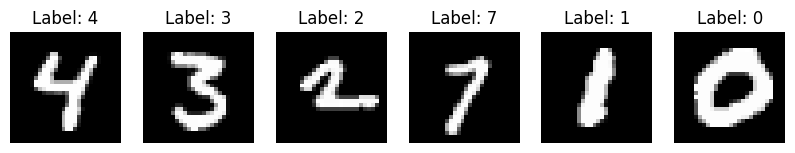

In [23]:
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(example_data[i][0], cmap='gray')
    axes[i].set_title(f"Label: {example_targets[i]}")
    axes[i].axis('off')

print("Sample shape:", example_data[0].shape)
plt.show()


## Step 3: Define the Baseline MLP Model¶
We will use this predefined **Multi-Layer Perceptron (MLP)** structure for the first experiment. 


In [24]:
class MLP1(nn.Module):
    def __init__(self):
        super(MLP1, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


### Questions:
Before training your model, answer the following questions in your final report:

1. **Can we change the input dimension (784) in `fc1`? Why or why not?**  


2. **Can we change the output dimension (10) in `fc3`? Why or why not?**  
 

3. **Can we change the dimensions of the hidden layers (`256` or `128`)? Why or why not?**  
   


## Step 3: Train and Evaluate the MLP Model
Use the following hyper-parameters:
- **Learning rate:** 0.1  
- **Batch size:** 32  
- **Epochs:** 10

Use Cross-Entropy loss as your loss function  


In [25]:
def train(model, loader, criterion, optimizer):
    model.train()
    correct, total = 0, 0
    for images, labels in loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return correct / total

def test(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


####  Training and Evaluation

In [26]:
model = MLP1()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

train_acc, test_acc = [], []

for epoch in range(10):
    tr_acc = train(model, train_loader, criterion, optimizer)
    te_acc = test(model, test_loader)
    train_acc.append(tr_acc)
    test_acc.append(te_acc)
    print(f"Epoch {epoch+1}: Train Acc={tr_acc:.4f}, Test Acc={te_acc:.4f}")


Epoch 1: Train Acc=0.6297, Test Acc=0.6740
Epoch 2: Train Acc=0.8460, Test Acc=0.8704
Epoch 3: Train Acc=0.8992, Test Acc=0.8509
Epoch 4: Train Acc=0.9127, Test Acc=0.9183
Epoch 5: Train Acc=0.9292, Test Acc=0.9205
Epoch 6: Train Acc=0.9485, Test Acc=0.9327
Epoch 7: Train Acc=0.9525, Test Acc=0.8983
Epoch 8: Train Acc=0.9643, Test Acc=0.9138
Epoch 9: Train Acc=0.9710, Test Acc=0.9411
Epoch 10: Train Acc=0.9725, Test Acc=0.9035


### Show your performance


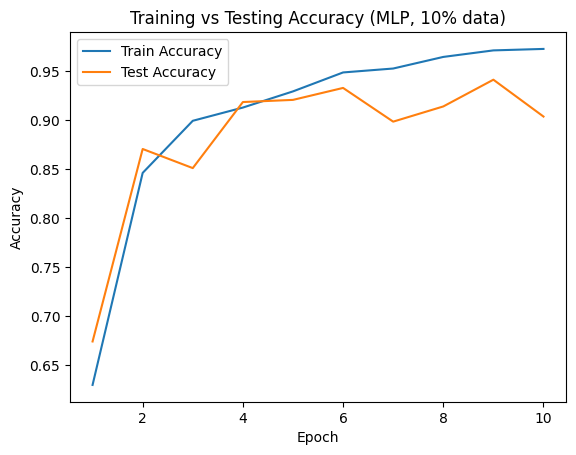

In [27]:
plt.plot(range(1, 11), train_acc, label='Train Accuracy')
plt.plot(range(1, 11), test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy (MLP, 10% data)')
plt.legend()
plt.show()


## Step 4: Using 30% of the Training Data
Now repeat the same process, but using **30%** of the training data.

Compare the new test accuracy to your previous results.

set seed to be 42 using torch.manual_seed(42)

Setup

In [28]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

## Load MNIST Dataset

In [29]:
# Transform: convert images to tensors and normalize to [-1, 1]
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

print(f"Training samples: {len(train_dataset)}, Testing samples: {len(test_dataset)}")


Training samples: 60000, Testing samples: 10000


## Load 30% of the Training Data

In [30]:
torch.manual_seed(42)  # fixed seed for reproducibility
train_size = int(0.3 * len(train_dataset))
_, small_train_dataset = random_split(train_dataset, [len(train_dataset) - train_size, train_size])

batch_size = 32

train_loader = DataLoader(small_train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Subset training samples: {len(small_train_dataset)}")


Subset training samples: 18000


## Visualize a Few MNIST Samples
Before training, let’s look at a few examples from the dataset.

Sample shape: torch.Size([1, 28, 28])


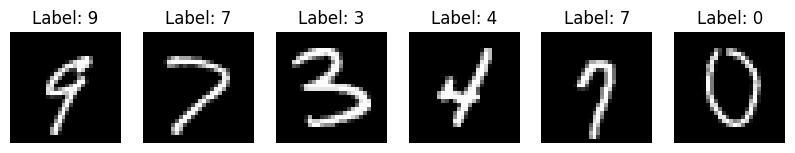

In [31]:
examples = enumerate(train_loader)
batch_idx, (example_data, example_targets) = next(examples)

fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(example_data[i][0], cmap='gray')
    axes[i].set_title(f"Label: {example_targets[i]}")
    axes[i].axis('off')

print("Sample shape:", example_data[0].shape)
plt.show()


## Define the Baseline MLP Model¶
We will use this predefined **Multi-Layer Perceptron (MLP)** structure


In [32]:
class MLP1(nn.Module):
    def __init__(self):
        super(MLP1, self).__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x


## Train and Evaluate the MLP Model
Using the following hyper-parameters:
- **Learning rate:** 0.1  
- **Batch size:** 32  
- **Epochs:** 10

Using Cross-Entropy loss as loss function  


In [33]:
def train(model, loader, criterion, optimizer):
    model.train()
    correct, total = 0, 0
    for images, labels in loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return correct / total

def test(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total


####  Training and Evaluation

In [34]:
model = MLP1()
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

train_acc, test_acc = [], []

for epoch in range(10):
    tr_acc = train(model, train_loader, criterion, optimizer)
    te_acc = test(model, test_loader)
    train_acc.append(tr_acc)
    test_acc.append(te_acc)
    print(f"Epoch {epoch+1}: Train Acc={tr_acc:.4f}, Test Acc={te_acc:.4f}")


Epoch 1: Train Acc=0.7871, Test Acc=0.9056
Epoch 2: Train Acc=0.9185, Test Acc=0.9239
Epoch 3: Train Acc=0.9388, Test Acc=0.9487
Epoch 4: Train Acc=0.9525, Test Acc=0.9502
Epoch 5: Train Acc=0.9608, Test Acc=0.9561
Epoch 6: Train Acc=0.9664, Test Acc=0.9536
Epoch 7: Train Acc=0.9719, Test Acc=0.9588
Epoch 8: Train Acc=0.9774, Test Acc=0.8760
Epoch 9: Train Acc=0.9817, Test Acc=0.9650
Epoch 10: Train Acc=0.9828, Test Acc=0.9668


### Show performance


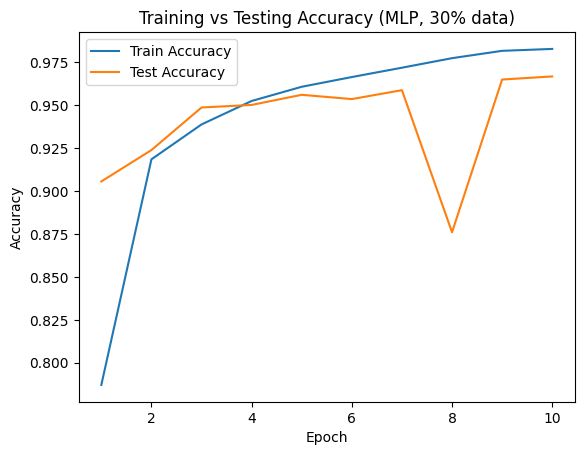

In [35]:
plt.plot(range(1, 11), train_acc, label='Train Accuracy')
plt.plot(range(1, 11), test_acc, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy (MLP, 30% data)')
plt.legend()
plt.show()

using 10%: 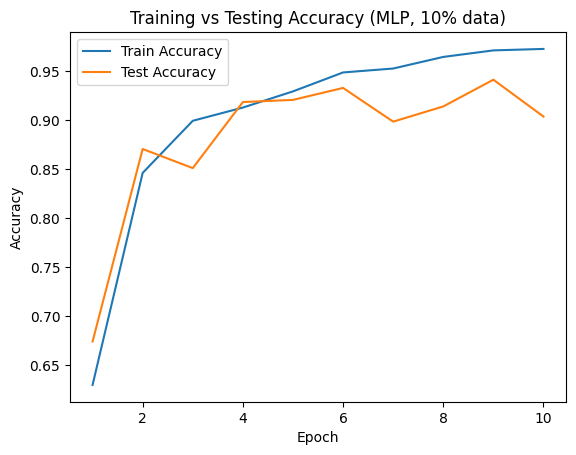

Epoch 1: Train Acc=0.6297, Test Acc=0.6740

Epoch 2: Train Acc=0.8458, Test Acc=0.8713

Epoch 3: Train Acc=0.8990, Test Acc=0.8505

Epoch 4: Train Acc=0.9145, Test Acc=0.9192

Epoch 5: Train Acc=0.9298, Test Acc=0.9190

Epoch 6: Train Acc=0.9498, Test Acc=0.9290

Epoch 7: Train Acc=0.9525, Test Acc=0.8971

Epoch 8: Train Acc=0.9630, Test Acc=0.9068

Epoch 9: Train Acc=0.9707, Test Acc=0.9422

Epoch 10: Train Acc=0.9718, Test Acc=0.8809

Using 30%: 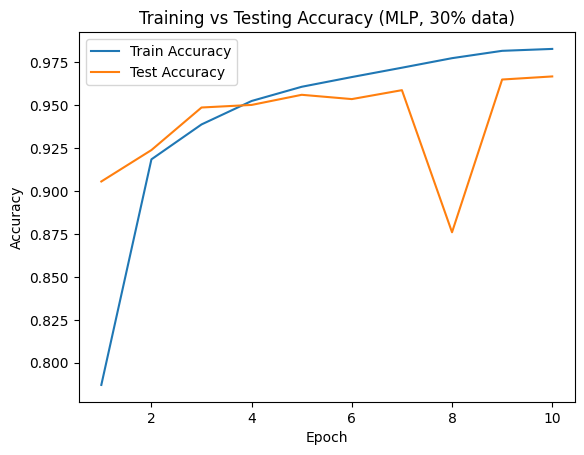

Epoch 1: Train Acc=0.7871, Test Acc=0.9056

Epoch 2: Train Acc=0.9185, Test Acc=0.9239

Epoch 3: Train Acc=0.9388, Test Acc=0.9487

Epoch 4: Train Acc=0.9525, Test Acc=0.9502

Epoch 5: Train Acc=0.9608, Test Acc=0.9561

Epoch 6: Train Acc=0.9664, Test Acc=0.9536

Epoch 7: Train Acc=0.9719, Test Acc=0.9588

Epoch 8: Train Acc=0.9774, Test Acc=0.8760

Epoch 9: Train Acc=0.9817, Test Acc=0.9650

Epoch 10: Train Acc=0.9828, Test Acc=0.9668

## Step 5: Design Your Own CNN Model
Now, design your own **Convolutional Neural Network (CNN)**.

Your **goal** is to beat the best MLP test accuracy using only 30% of the training data (same as Step 4)

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# -------------------------
# Hyperparameters
# -------------------------
BATCH_SIZE = 64
LR = 0.001
EPOCHS = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Transforms / Datasets / Loaders
# -------------------------

train_transform = transforms.Compose([

    # Randomly rotates images by 13 degrees
    transforms.RandomRotation(13),
    # Randomly crops the image
    transforms.RandomCrop(28, padding=1),
    # Transforms image to a PyTorch tensor and changes shape to (1, 28, 28)
    transforms.ToTensor()
])

# No augmentations in test transform
# You only want the model evaluated on clean, unmodified data.
test_transform = transforms.Compose([
    transforms.ToTensor()
])
train_dataset = datasets.MNIST(
    root="data", train=True, download=True, transform=train_transform
)
test_dataset = datasets.MNIST(
    root="data", train=False, download=True, transform=test_transform
)

# Setting it to test on only 30% of the data with a fixed seed for reproducibility
torch.manual_seed(13)
train_size = int(0.3 * len(train_dataset))
_, small_train_dataset = random_split(train_dataset, [len(train_dataset) - train_size, train_size])


# Loads the smaller dataset, shuffled
train_loader = DataLoader(small_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# Loads the full dataset when testing
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Subset training samples: {len(small_train_dataset)}")

# -------------------------
# Model (CNN architecture)
# -------------------------
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # These are the conv / relu / pool layers
            # Input: 1 x 28 x 28

            # nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
            # This one takes in one channel (since MNIST images are grayscale)
            # And extracts 16 features.
            # Output: 18 x 28 x 28
            nn.Conv2d(1, 18, 3, stride=1, padding=1),

            #nn.BatchNorm2d(num_features). Normalization to stabilize training
            nn.BatchNorm2d(18),

            # Activation function to add nonlinearity
            nn.ReLU(),

            # nn.MaxPool2d(kernel_size, stride)
            # Pooling layer. Shrinks spatial dimensions to condense info
            # This one halves size
            # Output: 18 x 14 x 14
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            # These are the Flatten(), Linear(), etc. layers

            # Outputs 18*14*14 = 3528. Needed prep for linear (fully connected) layers
            nn.Flatten(),
            nn.Linear(3528, 128),
            nn.ReLU(),
            # 50% chance that ReLU will be dropped. Helps avoid overfitting
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            # Outputs to logits for digits 0-9
            nn.Linear(64, 10)
        )

# Forward pass
    def forward(self, x):

        # Takes the input image, runs through all layers in self.features
        # Outputs a feature map
        x = self.features(x)

        # Takes the feature map, runs it through the classifier layers,
        # And outputs logits for the digits 0-9
        x = self.classifier(x)
        return x
    
model = MyCNN().to(device)

# -------------------------
# Loss / Optimizer
# -------------------------

# Loss function. Applies log_softmax to model outputs to convert them to probabilities
criterion = nn.CrossEntropyLoss()

# Penalizes network (big loss if it makes wrong choice with large confidence)
optimizer = optim.Adam(model.parameters(), lr=LR)

# -------------------------
# Training Function
# -------------------------
def train_one_epoch():
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

# -------------------------
# Evaluation Function
# -------------------------
def evaluate():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return acc

# -------------------------
# Main Training Loop
# -------------------------
for epoch in range(EPOCHS):
    loss = train_one_epoch()
    acc = evaluate()
    acc = acc * 100
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss {loss:.4f} | Test Accuracy {acc:.2f}%")

Subset training samples: 18000
Epoch 1/10 | Loss 0.7831 | Test Accuracy 94.99%
Epoch 2/10 | Loss 0.3998 | Test Accuracy 97.00%
Epoch 3/10 | Loss 0.3158 | Test Accuracy 97.30%
Epoch 4/10 | Loss 0.2713 | Test Accuracy 97.47%
Epoch 5/10 | Loss 0.2398 | Test Accuracy 97.74%
Epoch 6/10 | Loss 0.2402 | Test Accuracy 97.49%
Epoch 7/10 | Loss 0.2197 | Test Accuracy 98.13%
Epoch 8/10 | Loss 0.2119 | Test Accuracy 98.23%
Epoch 9/10 | Loss 0.2030 | Test Accuracy 98.43%
Epoch 10/10 | Loss 0.1924 | Test Accuracy 98.14%


## Step 6: Hyper-parameter and Learning Rate Exploration
Using the **same CNN** as Step 5, experiment with:
- Different learning rates  
- Optional learning rate schedulers (`StepLR`, `ReduceLROnPlateau`, etc.)
- Batch Size

Goal: **Improve the test accuracy** from your previous CNN experiment on Step 5.

****Different LR**** (0.001 -> 0.0005). Improved final accuracy (98.14 -> 98.41)

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# -------------------------
# Hyperparameters
# -------------------------
BATCH_SIZE = 64
LR = 0.0005
EPOCHS = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Transforms / Datasets / Loaders
# -------------------------

train_transform = transforms.Compose([

    # Randomly rotates images by 13 degrees
    transforms.RandomRotation(13),
    # Randomly crops the image
    transforms.RandomCrop(28, padding=1),
    # Transforms image to a PyTorch tensor and changes shape to (1, 28, 28)
    transforms.ToTensor()
])

# No augmentations in test transform
# You only want the model evaluated on clean, unmodified data.
test_transform = transforms.Compose([
    transforms.ToTensor()
])
train_dataset = datasets.MNIST(
    root="data", train=True, download=True, transform=train_transform
)
test_dataset = datasets.MNIST(
    root="data", train=False, download=True, transform=test_transform
)

# Setting it to test on only 30% of the data with a fixed seed for reproducibility
torch.manual_seed(13)
train_size = int(0.3 * len(train_dataset))
_, small_train_dataset = random_split(train_dataset, [len(train_dataset) - train_size, train_size])


# Loads the smaller dataset, shuffled
train_loader = DataLoader(small_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# Loads the full dataset when testing
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Subset training samples: {len(small_train_dataset)}")

# -------------------------
# Model (CNN architecture)
# -------------------------
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # These are the conv / relu / pool layers
            # Input: 1 x 28 x 28

            # nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
            # This one takes in one channel (since MNIST images are grayscale)
            # And extracts 16 features.
            # Output: 18 x 28 x 28
            nn.Conv2d(1, 18, 3, stride=1, padding=1),

            #nn.BatchNorm2d(num_features). Normalization to stabilize training
            nn.BatchNorm2d(18),

            # Activation function to add nonlinearity
            nn.ReLU(),

            # nn.MaxPool2d(kernel_size, stride)
            # Pooling layer. Shrinks spatial dimensions to condense info
            # This one halves size
            # Output: 18 x 14 x 14
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            # These are the Flatten(), Linear(), etc. layers

            # Outputs 18*14*14 = 3528. Needed prep for linear (fully connected) layers
            nn.Flatten(),
            nn.Linear(3528, 128),
            nn.ReLU(),
            # 50% chance that ReLU will be dropped. Helps avoid overfitting
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            # Outputs to logits for digits 0-9
            nn.Linear(64, 10)
        )

# Forward pass
    def forward(self, x):

        # Takes the input image, runs through all layers in self.features
        # Outputs a feature map
        x = self.features(x)

        # Takes the feature map, runs it through the classifier layers,
        # And outputs logits for the digits 0-9
        x = self.classifier(x)
        return x
    
model = MyCNN().to(device)

# -------------------------
# Loss / Optimizer
# -------------------------

# Loss function. Applies log_softmax to model outputs to convert them to probabilities
criterion = nn.CrossEntropyLoss()

# Penalizes network (big loss if it makes wrong choice with large confidence)
optimizer = optim.Adam(model.parameters(), lr=LR)

# -------------------------
# Training Function
# -------------------------
def train_one_epoch():
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

# -------------------------
# Evaluation Function
# -------------------------
def evaluate():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return acc

# -------------------------
# Main Training Loop
# -------------------------
for epoch in range(EPOCHS):
    loss = train_one_epoch()
    acc = evaluate()
    acc = acc * 100
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss {loss:.4f} | Test Accuracy {acc:.2f}%")

Subset training samples: 18000
Epoch 1/10 | Loss 0.8880 | Test Accuracy 94.12%
Epoch 2/10 | Loss 0.4357 | Test Accuracy 95.77%
Epoch 3/10 | Loss 0.3362 | Test Accuracy 96.97%
Epoch 4/10 | Loss 0.2829 | Test Accuracy 97.48%
Epoch 5/10 | Loss 0.2490 | Test Accuracy 97.66%
Epoch 6/10 | Loss 0.2395 | Test Accuracy 97.54%
Epoch 7/10 | Loss 0.2262 | Test Accuracy 98.14%
Epoch 8/10 | Loss 0.2139 | Test Accuracy 98.10%
Epoch 9/10 | Loss 0.2052 | Test Accuracy 98.15%
Epoch 10/10 | Loss 0.1914 | Test Accuracy 98.41%


Adding ****Optional learning rate schedulers**** (`StepLR`, `ReduceLROnPlateau`, etc.)

Also using a higher initial LR, increased final accuracy by 0.04% (98.41 -> 98.45)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# -------------------------
# Hyperparameters
# -------------------------
BATCH_SIZE = 64
LR = 0.0015
EPOCHS = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Transforms / Datasets / Loaders
# -------------------------

train_transform = transforms.Compose([

    # Randomly rotates images by 13 degrees
    transforms.RandomRotation(13),
    # Randomly crops the image
    transforms.RandomCrop(28, padding=1),
    # Transforms image to a PyTorch tensor and changes shape to (1, 28, 28)
    transforms.ToTensor()
])

# No augmentations in test transform
# You only want the model evaluated on clean, unmodified data.
test_transform = transforms.Compose([
    transforms.ToTensor()
])
train_dataset = datasets.MNIST(
    root="data", train=True, download=True, transform=train_transform
)
test_dataset = datasets.MNIST(
    root="data", train=False, download=True, transform=test_transform
)

# Setting it to test on only 30% of the data with a fixed seed for reproducibility
torch.manual_seed(13)
train_size = int(0.3 * len(train_dataset))
_, small_train_dataset = random_split(train_dataset, [len(train_dataset) - train_size, train_size])


# Loads the smaller dataset, shuffled
train_loader = DataLoader(small_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# Loads the full dataset when testing
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Subset training samples: {len(small_train_dataset)}")

# -------------------------
# Model (CNN architecture)
# -------------------------
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # These are the conv / relu / pool layers
            # Input: 1 x 28 x 28

            # nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
            # This one takes in one channel (since MNIST images are grayscale)
            # And extracts 16 features.
            # Output: 18 x 28 x 28
            nn.Conv2d(1, 18, 3, stride=1, padding=1),

            #nn.BatchNorm2d(num_features). Normalization to stabilize training
            nn.BatchNorm2d(18),

            # Activation function to add nonlinearity
            nn.ReLU(),

            # nn.MaxPool2d(kernel_size, stride)
            # Pooling layer. Shrinks spatial dimensions to condense info
            # This one halves size
            # Output: 18 x 14 x 14
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            # These are the Flatten(), Linear(), etc. layers

            # Outputs 18*14*14 = 3528. Needed prep for linear (fully connected) layers
            nn.Flatten(),
            nn.Linear(3528, 128),
            nn.ReLU(),
            # 50% chance that ReLU will be dropped. Helps avoid overfitting
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            # Outputs to logits for digits 0-9
            nn.Linear(64, 10)
        )

# Forward pass
    def forward(self, x):

        # Takes the input image, runs through all layers in self.features
        # Outputs a feature map
        x = self.features(x)

        # Takes the feature map, runs it through the classifier layers,
        # And outputs logits for the digits 0-9
        x = self.classifier(x)
        return x
    
model = MyCNN().to(device)

# -------------------------
# Loss / Optimizer
# -------------------------

# Loss function. Applies log_softmax to model outputs to convert them to probabilities
criterion = nn.CrossEntropyLoss()

# Penalizes network (big loss if it makes wrong choice with large confidence)
optimizer = optim.Adam(model.parameters(), lr=LR)

# -------------------------
# Training Function
# -------------------------
def train_one_epoch():
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

# -------------------------
# Evaluation Function
# -------------------------
def evaluate():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return acc

# -------------------------
# Scheduler
# -------------------------

# Every 2 epochs, LR is multiplied by gamma (cut by 33%)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma = 0.67)

# -------------------------
# Main Training Loop
# -------------------------
for epoch in range(EPOCHS):
    loss = train_one_epoch()
    acc = evaluate()

    scheduler.step()

    # Converts to percentage
    acc = acc * 100
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss {loss:.4f} | Test Accuracy {acc:.2f}%")

Subset training samples: 18000
Epoch 1/10 | Loss 0.7682 | Test Accuracy 95.33%
Epoch 2/10 | Loss 0.3885 | Test Accuracy 96.85%
Epoch 3/10 | Loss 0.2966 | Test Accuracy 97.49%
Epoch 4/10 | Loss 0.2588 | Test Accuracy 97.43%
Epoch 5/10 | Loss 0.2177 | Test Accuracy 98.01%
Epoch 6/10 | Loss 0.2185 | Test Accuracy 98.20%
Epoch 7/10 | Loss 0.1917 | Test Accuracy 98.21%
Epoch 8/10 | Loss 0.1927 | Test Accuracy 98.24%
Epoch 9/10 | Loss 0.1737 | Test Accuracy 98.41%
Epoch 10/10 | Loss 0.1716 | Test Accuracy 98.45%


**Changing batch size**

Reducing batch size from 64 -> 32 further improved final accuracy by 0.01% (98.45 -> 98.46)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# -------------------------
# Hyperparameters
# -------------------------
BATCH_SIZE = 32
LR = 0.0015
EPOCHS = 10

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# -------------------------
# Transforms / Datasets / Loaders
# -------------------------

train_transform = transforms.Compose([

    # Randomly rotates images by 13 degrees
    transforms.RandomRotation(13),
    # Randomly crops the image
    transforms.RandomCrop(28, padding=1),
    # Transforms image to a PyTorch tensor and changes shape to (1, 28, 28)
    transforms.ToTensor()
])

# No augmentations in test transform
# You only want the model evaluated on clean, unmodified data.
test_transform = transforms.Compose([
    transforms.ToTensor()
])
train_dataset = datasets.MNIST(
    root="data", train=True, download=True, transform=train_transform
)
test_dataset = datasets.MNIST(
    root="data", train=False, download=True, transform=test_transform
)

# Setting it to test on only 30% of the data with a fixed seed for reproducibility
torch.manual_seed(13)
train_size = int(0.3 * len(train_dataset))
_, small_train_dataset = random_split(train_dataset, [len(train_dataset) - train_size, train_size])


# Loads the smaller dataset, shuffled
train_loader = DataLoader(small_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
# Loads the full dataset when testing
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Subset training samples: {len(small_train_dataset)}")

# -------------------------
# Model (CNN architecture)
# -------------------------
class MyCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            # These are the conv / relu / pool layers
            # Input: 1 x 28 x 28

            # nn.Conv2d(in_channels, out_channels, kernel_size, stride=1, padding=0)
            # This one takes in one channel (since MNIST images are grayscale)
            # And extracts 16 features.
            # Output: 18 x 28 x 28
            nn.Conv2d(1, 18, 3, stride=1, padding=1),

            #nn.BatchNorm2d(num_features). Normalization to stabilize training
            nn.BatchNorm2d(18),

            # Activation function to add nonlinearity
            nn.ReLU(),

            # nn.MaxPool2d(kernel_size, stride)
            # Pooling layer. Shrinks spatial dimensions to condense info
            # This one halves size
            # Output: 18 x 14 x 14
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            # These are the Flatten(), Linear(), etc. layers

            # Outputs 18*14*14 = 3528. Needed prep for linear (fully connected) layers
            nn.Flatten(),
            nn.Linear(3528, 128),
            nn.ReLU(),
            # 50% chance that ReLU will be dropped. Helps avoid overfitting
            nn.Dropout(0.5),
            nn.Linear(128, 64),
            nn.ReLU(),
            # Outputs to logits for digits 0-9
            nn.Linear(64, 10)
        )

# Forward pass
    def forward(self, x):

        # Takes the input image, runs through all layers in self.features
        # Outputs a feature map
        x = self.features(x)

        # Takes the feature map, runs it through the classifier layers,
        # And outputs logits for the digits 0-9
        x = self.classifier(x)
        return x
    
model = MyCNN().to(device)

# -------------------------
# Loss / Optimizer
# -------------------------

# Loss function. Applies log_softmax to model outputs to convert them to probabilities
criterion = nn.CrossEntropyLoss()

# Penalizes network (big loss if it makes wrong choice with large confidence)
optimizer = optim.Adam(model.parameters(), lr=LR)

# -------------------------
# Training Function
# -------------------------
def train_one_epoch():
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(train_loader)

# -------------------------
# Evaluation Function
# -------------------------
def evaluate():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    acc = correct / total
    return acc

# -------------------------
# Scheduler
# -------------------------

# Every 2 epochs, LR is multiplied by gamma (cut by 33%)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=2, gamma = 0.67)

# -------------------------
# Main Training Loop
# -------------------------
for epoch in range(EPOCHS):
    loss = train_one_epoch()
    acc = evaluate()

    scheduler.step()

    # Converts to percentage
    acc = acc * 100
    
    print(f"Epoch {epoch+1}/{EPOCHS} | Loss {loss:.4f} | Test Accuracy {acc:.2f}%")

Subset training samples: 18000
Epoch 1/10 | Loss 0.7209 | Test Accuracy 95.46%
Epoch 2/10 | Loss 0.3896 | Test Accuracy 96.55%
Epoch 3/10 | Loss 0.2862 | Test Accuracy 97.69%
Epoch 4/10 | Loss 0.2502 | Test Accuracy 97.32%
Epoch 5/10 | Loss 0.2153 | Test Accuracy 97.98%
Epoch 6/10 | Loss 0.2074 | Test Accuracy 98.18%
Epoch 7/10 | Loss 0.1886 | Test Accuracy 98.27%
Epoch 8/10 | Loss 0.1861 | Test Accuracy 98.34%
Epoch 9/10 | Loss 0.1739 | Test Accuracy 98.13%
Epoch 10/10 | Loss 0.1616 | Test Accuracy 98.46%


## Step 7: Analysis
Write a short report discussing the following points:
1. **Effect of Data Size:**  
   How did the amount of training data (10% vs 30%) affect your model’s generalization performance?  
   
2. **Effect of Model Architecture:**  
   How did different network architectures (MLP vs CNN) impact generalization?

3. **Effect of Learning Rate:**  
   How did the choice of learning rate (and/or use of a learning rate scheduler) influence **convergence** speed and final performance?

4. **Effective Design Choices:**  
   Which design decisions (e.g., number of layers, hidden dimension, activation functions, batch size) in your experiments contributed most to improving the model's generalization performance?

5. **Limitations and Improvement Strategies:**  
   What limitations or challenges did you observe in your experiments (e.g., overfitting, slow convergence, unstable training)?  
   Suggest one or two strategies that could further improve model performance.